In [36]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [37]:
import matplotlib.pyplot as plt

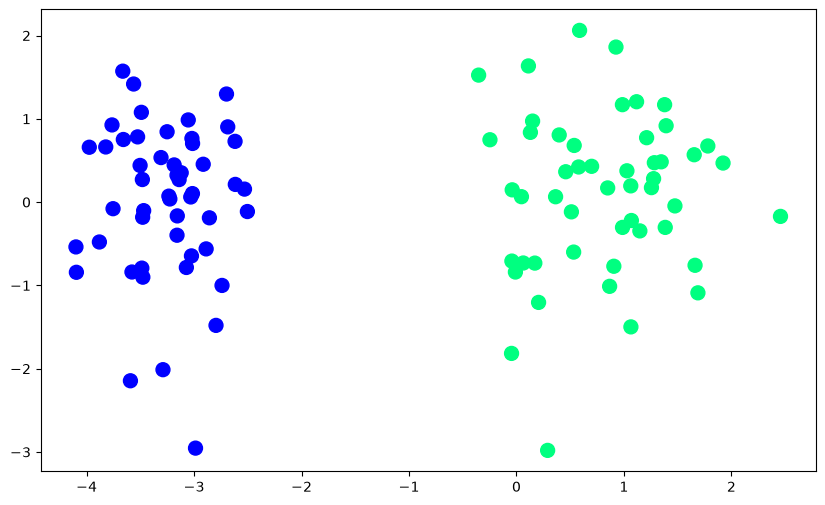

In [38]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [39]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty='none',solver='sag')
try:
    lor.fit(X, y)
except Exception as e:
    if "penalty" in str(e).lower() and "none" in str(e).lower():
        lor = LogisticRegression(penalty=None, solver='sag')
        lor.fit(X, y)
    else:
        raise

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [40]:
print(lor.coef_)
print(lor.intercept_)

[[4.80228802 0.21267539]]
[5.77259367]


In [41]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [42]:
m1, b1

(np.float64(-22.580365838680336), array([-27.14274452]))

In [43]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [44]:
x_input, y_input

(array([-3.        , -2.93939394, -2.87878788, -2.81818182, -2.75757576,
        -2.6969697 , -2.63636364, -2.57575758, -2.51515152, -2.45454545,
        -2.39393939, -2.33333333, -2.27272727, -2.21212121, -2.15151515,
        -2.09090909, -2.03030303, -1.96969697, -1.90909091, -1.84848485,
        -1.78787879, -1.72727273, -1.66666667, -1.60606061, -1.54545455,
        -1.48484848, -1.42424242, -1.36363636, -1.3030303 , -1.24242424,
        -1.18181818, -1.12121212, -1.06060606, -1.        , -0.93939394,
        -0.87878788, -0.81818182, -0.75757576, -0.6969697 , -0.63636364,
        -0.57575758, -0.51515152, -0.45454545, -0.39393939, -0.33333333,
        -0.27272727, -0.21212121, -0.15151515, -0.09090909, -0.03030303,
         0.03030303,  0.09090909,  0.15151515,  0.21212121,  0.27272727,
         0.33333333,  0.39393939,  0.45454545,  0.51515152,  0.57575758,
         0.63636364,  0.6969697 ,  0.75757576,  0.81818182,  0.87878788,
         0.93939394,  1.        ,  1.06060606,  1.1

In [45]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

# We have used Batch GD

In [46]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

In [47]:
coef_,intercept_ = gd(X,y)

In [48]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [53]:
m, b

(np.float64(-22.84586207917223), np.float64(-27.5390354119192))

In [49]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

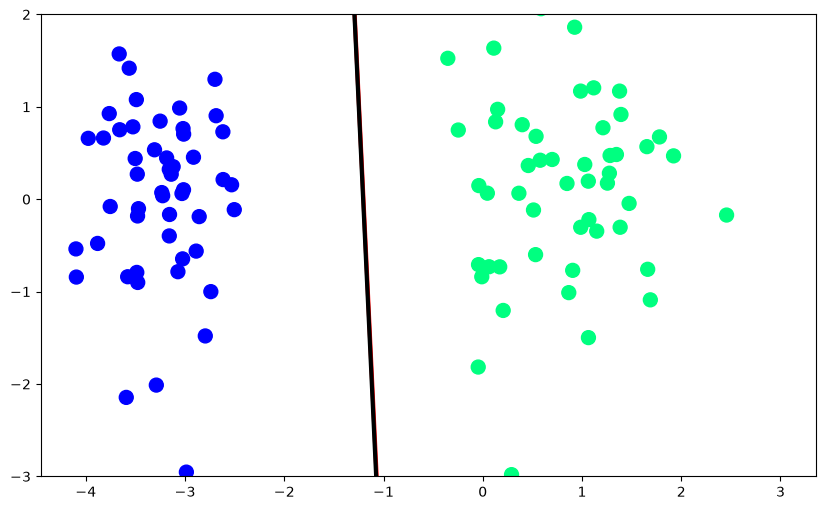

In [50]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3) # scikit learn
plt.plot(x_input1,y_input1,color='black',linewidth=3)  # Our model
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [51]:
np.insert(X,0,1,axis=1)

array([[ 1.        ,  0.51123145, -0.11697552],
       [ 1.        ,  0.06316371, -0.73115232],
       [ 1.        , -0.0425064 , -0.7081059 ],
       [ 1.        , -3.2891569 , -2.01199214],
       [ 1.        ,  0.1111445 ,  1.63493163],
       [ 1.        , -2.53070306,  0.15599044],
       [ 1.        , -3.49036198,  1.07782053],
       [ 1.        ,  0.3976447 ,  0.80626713],
       [ 1.        , -0.24666899,  0.74859527],
       [ 1.        , -3.65803446,  0.75152794],
       [ 1.        , -3.47658131, -0.90114581],
       [ 1.        , -3.47815037, -0.1815243 ],
       [ 1.        ,  0.29004249, -2.98092432],
       [ 1.        ,  1.11761831,  1.20500136],
       [ 1.        , -3.52530398,  0.78302407],
       [ 1.        ,  0.69929128,  0.42968688],
       [ 1.        ,  0.17089733, -0.73229726],
       [ 1.        , -3.57785124, -0.83930476],
       [ 1.        ,  0.12965489,  0.83727062],
       [ 1.        , -3.46888717, -0.10255323],
       [ 1.        , -3.97487212,  0.658

In [52]:
X1 = np.insert(X,0,1,axis=1)
np.ones(X1.shape[1])

array([1., 1., 1.])